디커플링 발생(t=상위10% 진입) 이벤트 수: 7

[전조 양상 TOP 20] (상대월 -6~-1 중 반복 비율이 큰 것)


C:\Users\김가은\AppData\Local\Temp\ipykernel_10552\2850359525.py:129: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["top_entry"] = df["top10"] & (~df["top10"].shift(1).fillna(False))


,변수,상대월,유형,상승비율,하락비율,표본수,강도
26,신용스프레드,-3,수준(z),0.285714,0.000000,7,0.285714
20,소매판매,-6,수준(z),0.000000,0.285714,7,0.285714
24,신용스프레드,-6,수준(z),0.285714,0.000000,7,0.285714
0,환율,-6,수준(z),0.000000,0.142857,7,0.142857
10,M2,-3,수준(z),0.142857,0.142857,7,0.142857
6,CPI,-3,수준(z),0.142857,0.142857,7,0.142857
8,M2,-6,수준(z),0.142857,0.142857,7,0.142857
22,소매판매,-3,수준(z),0.000000,0.142857,7,0.142857
12,코스피,-6,수준(z),0.000000,0.142857,7,0.142857
1,환율,-6,변화(Δz),0.000000,0.142857,7,0.142857


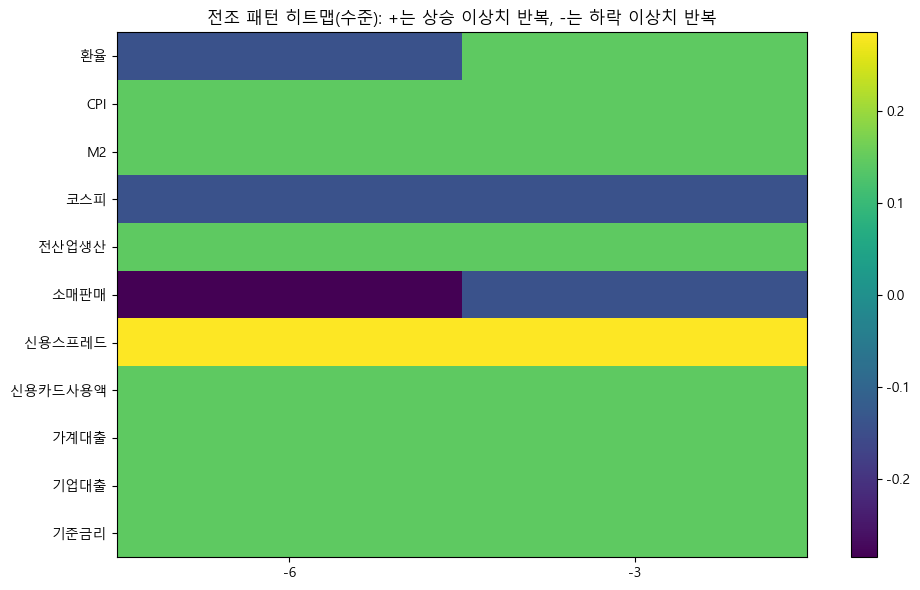

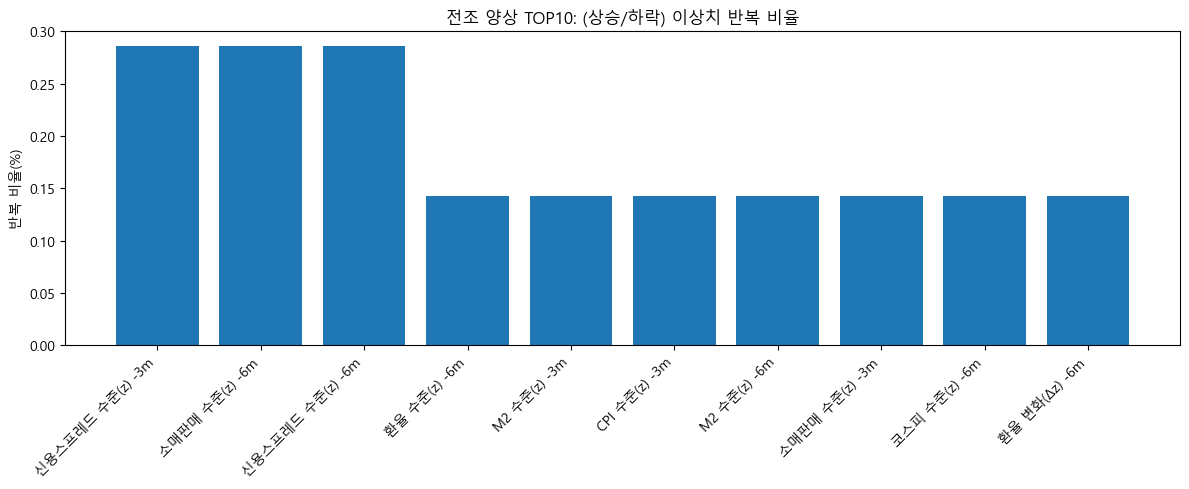

In [13]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = "./data"

# --- 파일 경로(전처리_ 파일명 그대로) ---
def must(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"파일 없음: {path}")
    return path

# decoupling은 이름이 다를 수 있어서 자동 탐색
dec_candidates = sorted(glob.glob(os.path.join(DATA_DIR, "decoupling*.csv")))
if not dec_candidates:
    raise FileNotFoundError(f"{DATA_DIR} 안에 decoupling*.csv 파일이 없습니다.")
DEC_PATH = dec_candidates[0]

PATHS = {
    "디커플링": DEC_PATH,
    "CPI": must(os.path.join(DATA_DIR, "전처리_cpi.csv")),
    "M2": must(os.path.join(DATA_DIR, "전처리_M2.csv")),
    "가계대출": must(os.path.join(DATA_DIR, "전처리_가계대출.csv")),
    "기업대출": must(os.path.join(DATA_DIR, "전처리_기업대출.csv")),
    "기준금리": must(os.path.join(DATA_DIR, "전처리_기준금리.csv")),
    "소매판매액지수": must(os.path.join(DATA_DIR, "전처리_소매판매액지수.csv")),
    "신용스프레드": must(os.path.join(DATA_DIR, "전처리_신용스프레드.csv")),
    "신용카드사용액": must(os.path.join(DATA_DIR, "전처리_신용카드사용액.csv")),
    "전산업생산지수": must(os.path.join(DATA_DIR, "전처리_전산업생산지수.csv")),
    "코스피": must(os.path.join(DATA_DIR, "전처리_코스피.csv")),
    "환율": must(os.path.join(DATA_DIR, "전처리_환율.csv")),
}

def read_csv(path):
    df = pd.read_csv(path)
    # date 이름 자동 처리
    for c in ["date","Date","DATE","날짜","시점","기간"]:
        if c in df.columns:
            df = df.rename(columns={c:"date"})
            break
    if "date" not in df.columns:
        raise ValueError(f"{path}: date 컬럼이 없습니다. 컬럼={list(df.columns)}")
    df["date"] = pd.to_datetime(df["date"])
    return df.sort_values("date").reset_index(drop=True)

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    # fallback: date 제외 숫자열
    best = None
    best_nonnull = -1
    for c in df.columns:
        if c == "date": 
            continue
        s = pd.to_numeric(df[c], errors="coerce")
        nn = s.notna().sum()
        if nn > best_nonnull:
            best, best_nonnull = c, nn
    if best is None:
        raise ValueError("값 컬럼을 찾지 못함")
    return best

# --- 로드 ---
dec = read_csv(PATHS["디커플링"])
cpi = read_csv(PATHS["CPI"])
m2 = read_csv(PATHS["M2"])
hh = read_csv(PATHS["가계대출"])
corp = read_csv(PATHS["기업대출"])
rate = read_csv(PATHS["기준금리"])
ret = read_csv(PATHS["소매판매액지수"])
spr = read_csv(PATHS["신용스프레드"])
card = read_csv(PATHS["신용카드사용액"])
ipi = read_csv(PATHS["전산업생산지수"])
kospi = read_csv(PATHS["코스피"])
fx = read_csv(PATHS["환율"])

# --- 컬럼 표준화 ---
gap_col = pick_col(dec, ["gap"])
dec = dec[["date", gap_col]].rename(columns={gap_col:"gap"})

cpi_col = pick_col(cpi, ["cpi","CPI"])
cpi = cpi[["date", cpi_col]].rename(columns={cpi_col:"cpi"})

m2_col = pick_col(m2, ["M2","m2"])
m2 = m2[["date", m2_col]].rename(columns={m2_col:"m2"})

hh_col = pick_col(hh, ["hh_loan","가계대출"])
hh = hh[["date", hh_col]].rename(columns={hh_col:"hh_loan"})

corp_col = pick_col(corp, ["산업별대출금","corp_loan","기업대출"])
corp = corp[["date", corp_col]].rename(columns={corp_col:"corp_loan"})

rate_col = pick_col(rate, ["한국은행 기준금리","기준금리","base_rate"])
rate = rate[["date", rate_col]].rename(columns={rate_col:"base_rate"})

# retail_z가 있으면 그걸 우선(없으면 자동선택한 컬럼을 retail_z로)
ret_col = "retail_z" if "retail_z" in ret.columns else pick_col(ret, ["retail_z","yoy","value"])
ret = ret[["date", ret_col]].rename(columns={ret_col:"retail_z"})

spr_col = pick_col(spr, ["credit_spread","신용스프레드","스프레드"])
spr = spr[["date", spr_col]].rename(columns={spr_col:"credit_spread"})

card_col = pick_col(card, ["value","card_value","사용액"])
card = card[["date", card_col]].rename(columns={card_col:"card_value"})

ipi_col = pick_col(ipi, ["ipi","전산업생산지수"])
ipi = ipi[["date", ipi_col]].rename(columns={ipi_col:"ipi"})

kospi_col = pick_col(kospi, ["kospi","코스피"])
kospi = kospi[["date", kospi_col]].rename(columns={kospi_col:"kospi"})

fx_col = pick_col(fx, ["exchange","환율"])
fx = fx[["date", fx_col]].rename(columns={fx_col:"exchange"})

# --- 병합 ---
df = dec
for d in [cpi,m2,hh,corp,rate,ret,spr,card,ipi,kospi,fx]:
    df = df.merge(d, on="date", how="inner")
df = df.sort_values("date").reset_index(drop=True)

# --- 디커플링 발생 시점 t (상위10% 진입) ---
top_cut = df["gap"].quantile(0.90)
df["top10"] = df["gap"] >= top_cut
df["top_entry"] = df["top10"] & (~df["top10"].shift(1).fillna(False))
events = df.loc[df["top_entry"], "date"].tolist()
print("디커플링 발생(t=상위10% 진입) 이벤트 수:", len(events))

# --- z-score + Δz 만들기 ---
VARS = {
    "환율":"exchange",
    "CPI":"cpi",
    "M2":"m2",
    "코스피":"kospi",
    "전산업생산":"ipi",
    "소매판매":"retail_z",
    "신용스프레드":"credit_spread",
    "신용카드사용액":"card_value",
    "가계대출":"hh_loan",
    "기업대출":"corp_loan",
    "기준금리":"base_rate",
}

for k, col in VARS.items():
    s = pd.to_numeric(df[col], errors="coerce")
    sd = s.std(ddof=0)
    df[f"{k}_z"] = (s - s.mean()) / (sd if sd and sd!=0 else 1.0)
    df[f"{k}_dz"] = df[f"{k}_z"].diff()

df_idx = df.set_index("date")

# --- 전조 구간(-6~-1)에서 "같은 양상"이 반복되는지 집계 ---
REL = [-6,-5,-4,-3,-2,-1]
Z_THR = 1.0      # 수준 비정상 기준
DZ_THR = 1.0     # 변화 비정상 기준

def flag_level(x):
    # (+)상승 이상치 / (-)하락 이상치
    if pd.isna(x): return 0
    if x >= Z_THR: return +1
    if x <= -Z_THR: return -1
    return 0

def flag_change(x):
    if pd.isna(x): return 0
    if x >= DZ_THR: return +1
    if x <= -DZ_THR: return -1
    return 0

# 결과 저장: (변수, 상대월, type[level/change])별로
rows = []
for var in VARS.keys():
    for r in REL:
        # 각 이벤트마다 해당 상대월의 상태를 모아 방향성 집계
        level_flags = []
        change_flags = []
        for t in events:
            dt = t + pd.DateOffset(months=r)
            if dt in df_idx.index:
                level_flags.append(flag_level(df_idx.loc[dt, f"{var}_z"]))
                change_flags.append(flag_change(df_idx.loc[dt, f"{var}_dz"]))
        if len(level_flags) == 0:
            continue

        # 같은 방향 반복 비율: 상승(+1) 비율 / 하락(-1) 비율
        lf = np.array(level_flags)
        cf = np.array(change_flags)

        up_level = (lf==+1).mean()
        down_level = (lf==-1).mean()
        up_change = (cf==+1).mean()
        down_change = (cf==-1).mean()

        rows.append([var, r, "수준(z)", up_level, down_level, len(lf)])
        rows.append([var, r, "변화(Δz)", up_change, down_change, len(cf)])

summary = pd.DataFrame(rows, columns=["변수","상대월","유형","상승비율","하락비율","표본수"])

# --- 가장 강한 전조 양상 TOP ---
# 기준: max(상승비율, 하락비율)이 큰 순 (표본수도 너무 적으면 제외)
summary["강도"] = summary[["상승비율","하락비율"]].max(axis=1)
summary_f = summary[summary["표본수"] >= max(3, int(len(events)*0.6))].copy()  # 최소 표본 조건(필요시 완화)
top_patterns = summary_f.sort_values("강도", ascending=False).head(20)

print("\n[전조 양상 TOP 20] (상대월 -6~-1 중 반복 비율이 큰 것)")
display(top_patterns)

# --- 포트폴리오용 시각화 1: 변수×상대월 히트맵(수준) ---
pivot_level = summary[summary["유형"]=="수준(z)"].copy()
pivot_level["방향강도"] = np.where(pivot_level["상승비율"]>=pivot_level["하락비율"],
                                pivot_level["상승비율"],
                                -pivot_level["하락비율"])
heat = pivot_level.pivot(index="변수", columns="상대월", values="방향강도").reindex(index=list(VARS.keys()))

plt.figure(figsize=(10,6))
plt.imshow(heat.values, aspect="auto")
plt.xticks(np.arange(len(heat.columns)), heat.columns)
plt.yticks(np.arange(len(heat.index)), heat.index)
plt.title("전조 패턴 히트맵(수준): +는 상승 이상치 반복, -는 하락 이상치 반복")
plt.colorbar()
plt.tight_layout()
plt.show()

# --- 포트폴리오용 시각화 2: TOP 패턴 막대(비율) ---
tp = top_patterns.head(10).copy()
labels = [f"{r['변수']} {r['유형']} {r['상대월']}m" for _, r in tp.iterrows()]
vals = tp["강도"].values
plt.figure(figsize=(12,5))
plt.bar(np.arange(len(vals)), vals)
plt.xticks(np.arange(len(vals)), labels, rotation=45, ha="right")
plt.title("전조 양상 TOP10: (상승/하락) 이상치 반복 비율")
plt.ylabel("반복 비율(%)")
plt.tight_layout()
plt.show()